# M5A1 - Inspeção Visual de Itens em Esteira de Manufatura

> **Resumo:** Primeiro projeto real do módulo! Treinamos (refinamos) um detector **YOLOv11** para inspeção visual numa esteira de manufatura: baixamos um dataset do Hugging Face, treinamos a YOLO, rodamos a detecção num **vídeo** da esteira e testamos a robustez do modelo fora-de-distribuição (o Sonic).

> ⚠️ **GPU recomendada** (Ambiente de execução → Alterar o tipo → GPU T4): o `model.train(...)` da YOLO roda muito mais rápido em GPU.

Na prática de hoje vamos refinar um modelo para a tarefa de inspeção visual de itens em uma esteira de manufatura.

Na indústria de manufatura, a inspeção visual manual é suscetível a erros devido à fadiga humana e à alta velocidade das linhas de produção. A automatização com visão computacional é ideal nesses cenários. No entanto, um desafio clássico é que defeitos reais de fabricação são raros, resultando em bases de dados extremamente desbalanceadas.

Para contornar esse problema, técnicas de **Data Augmentation** e geração de dados sintéticos por meio de **Modelos Generativos** (como GANs ou Modelos de Difusão) são amplamente utilizadas para enriquecer a base com exemplos realistas de peças defeituosas. Além disso, modelos de detecção baseados em **CNNs** (como a família YOLO) são empregados para classificar e, ao mesmo tempo, localizar as anomalias nas peças.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Próximos passos
- Atividades Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [ ]:
!pip install torch torchvision huggingface_hub ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.7 MB/s eta 0:00:00


Importar as bibliotecas

In [ ]:
import yaml
import os

from ultralytics import YOLO
from huggingface_hub import snapshot_download
from pathlib import Path
import shutil
from IPython.display import Video

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/johnatanvq/fruits-dataset

In [ ]:
# 1) Baixar somente o subdiretório fruitsData/
local_repo_dir = snapshot_download(
    repo_id="johnatanvq/fruits-dataset",
    repo_type="dataset",
    allow_patterns=["fruitsData/**"],  # baixa só essa pasta
)

print("Arquivos baixados em:", local_repo_dir)

# 2) Mover/copiar para uma pasta final estilo ImageFolder (se quiser customizar o caminho)
src = Path(local_repo_dir) / "fruitsData"
dst = Path("data/fruits")  # pasta final onde você quer o ImageFolder

# Copiando arquivos para dst.
if dst.exists():
    shutil.rmtree(dst)
shutil.copytree(src, dst)

print("ImageFolder pronto em:", dst)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 322 files:   0%|          | 0/322 [00:00<?, ?it/s]

Arquivos baixados em: /root/.cache/huggingface/hub/datasets--johnatanvq--fruits-dataset/snapshots/7cf7e5de00d186e99fe46357a80be02f3e110a34
ImageFolder pronto em: data/fruits


In [ ]:
def create_data_yaml(path_to_classes_txt, path_to_data_yaml):
  # Lê o arquivos "classes.txt".
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Cria o dicionário a ser salvo.
  data = {
      'path': 'data/fruits',
      'train': 'images',
      'val': 'images',
      'nc': number_of_classes,
      'names': classes
  }

  # Escreve o arquivo YAML.
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Chama a função.
create_data_yaml("data/fruits/classes.txt", "yolo_train.yaml")

Created config file at yolo_train.yaml


In [ ]:
# Carrega o modelo pré-treinado.
model = YOLO("yolo11n.pt")

# Treina o modelo utilizando as informações do arquivo YAML.
# Definimos também a quantidade de épocas, o batch, e o tamanho das imagens.
results = model.train(data="./yolo_train.yaml", project="praticas/modulo_5/aula_1", epochs=10, batch=2, imgsz=480)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_train.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

In [ ]:
# Visualizar o vídeo original.
Video("video.mov")

In [ ]:
# Rodar predição do modelo no vídeo e salvar os resultados de forma determinística
# Usando name="predict" e exist_ok=True para evitar a criação de múltiplas pastas (predict2, predict3, etc.)
pred_video_results = model.predict("video.mov", save=True, project="praticas/modulo_5/aula_1", name="predict", exist_ok=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/239) /content/video.mov: 288x480 2 apples, 2 oranges, 66.7ms
video 1/1 (frame 2/239) /content/video.mov: 288x480 2 apples, 2 oranges, 12.5ms
video 1/1 (frame 3/239) /content/video.mov: 288x480 2 apples, 2 oranges, 12.8ms
video 1/1 (frame 4/239) /content/video.mov: 288x480 2 apples, 1 orange, 11.9ms
video 1/1 (frame 5/239) /content/video.mov: 288x480 2 apples, 2 oranges, 12.3ms
video 1/1 (frame 6/239) /content/video.mov: 288x480 2 apple

In [ ]:
# Exibir o vídeo com as predições do YOLO (resolvendo o caminho absoluto de forma dinâmica)
import glob, os
# A ultralytics costuma salvar sob 'runs/detect/...'; pegamos o diretório real do resultado.
save_dir = str(pred_video_results[0].save_dir)
predict_videos = glob.glob(os.path.join(save_dir, "video.*"))
if not predict_videos:  # fallback: busca recursiva caso a estrutura mude
    predict_videos = glob.glob("**/predict/video.*", recursive=True)
if predict_videos:
    video_to_show = predict_videos[0]
    print(f"Exibindo vídeo resultante: {video_to_show}")
    Video(video_to_show)
else:
    print("Nenhum vídeo resultante de predição foi encontrado em 'praticas/modulo_5/aula_1/predict/'")

Exibindo vídeo resultante: /content/runs/detect/praticas/modulo_5/aula_1/predict/video.avi


## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.ultralytics.com/modes/train/
- https://docs.ultralytics.com/modes/predict/
- https://huggingface.co/datasets/johnatanvq/fruits-dataset
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] **Teste de Robustez com Team Sonic (Out-of-Distribution)** — resolvida logo abaixo (leve: só inferência no modelo já treinado).
- [x] **Comparação de hiperparâmetros** — resolvida na seção opcional/pesada no fim (re-treina a YOLO).
- [ ] **Sugestão livre:** troque o dataset de frutas por outro do Hugging Face e veja se o pipeline continua funcionando.

Vamos rodar o modelo treinado em uma imagem do Sonic para ver se ele faz falsas detecções ou ignora a imagem corretamente, já que o Sonic não faz parte do dataset de frutas!

Imagem do Sonic encontrada em: /content/sonic.jpg

image 1/1 /content/sonic.jpg: 288x480 1 carrot, 15.4ms
Speed: 2.1ms preprocess, 15.4ms inference, 1.7ms postprocess per image at shape (1, 3, 288, 480)
Results saved to /content/runs/detect/praticas/modulo_5/aula_1/predict_sonic


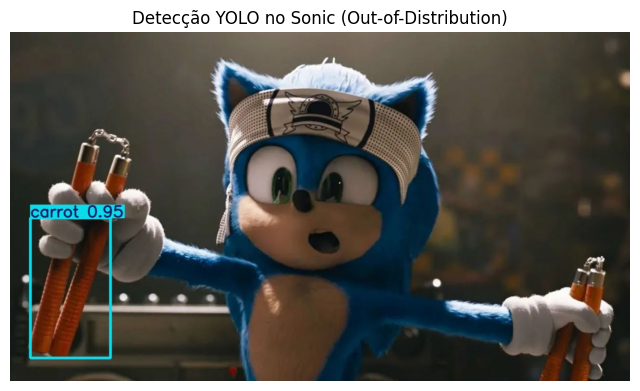

In [11]:
import os

# Caminho para a imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    print(f"Imagem do Sonic encontrada em: {sonic_path}")
    # Rodar predição do YOLO na imagem do Sonic
    # Usando predict_sonic e exist_ok=True para garantir um caminho previsível
    sonic_results = model.predict(sonic_path, save=True, project="praticas/modulo_5/aula_1", name="predict_sonic", exist_ok=True)

    # Exibir a imagem resultante com as detecções do YOLO (usando o save_dir real da ultralytics,
    # que costuma ficar sob 'runs/detect/...')
    predicted_sonic_path = os.path.join(str(sonic_results[0].save_dir), "sonic.jpg")
    if os.path.exists(predicted_sonic_path):
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg
        img = mpimg.imread(predicted_sonic_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Detecção YOLO no Sonic (Out-of-Distribution)")
        plt.show()
    else:
        print("Não foi possível carregar a imagem predita do Sonic.")

a identificação de carrot kkkk

---
# ⏸️ Ponto de parada

## Atividade (opcional/pesada): Comparação de Hiperparâmetros

Treinamos uma **segunda** YOLO com uma configuração mais "enxuta" (menos épocas, imagem menor,
batch maior) e comparamos a qualidade de detecção (**mAP**) com o treino original. Assim dá pra
sentir o trade-off entre tempo de treino e desempenho.

In [ ]:
# Segundo treino com hiperparâmetros diferentes (config enxuta: mais rápida)
model_v2 = YOLO("yolo11n.pt")
results_v2 = model_v2.train(data="./yolo_train.yaml", project="praticas/modulo_5/aula_1",
                            name="train_v2", exist_ok=True, epochs=5, batch=4, imgsz=320)

# Extrai as métricas de cada treino de forma robusta (mAP50 e mAP50-95)
def get_map(res):
    try:
        return res.box.map50, res.box.map
    except Exception:
        return None, None

m50_v1, m_v1 = get_map(results)
m50_v2, m_v2 = get_map(results_v2)

def fmt(v):
    return f"{v:.3f}" if isinstance(v, (int, float)) else "n/d"

print("=== Comparação de configurações da YOLO ===")
print(f"{'Config':<30} {'mAP50':<10} {'mAP50-95':<10}")
print(f"{'Original (ep=10, bs=2, 480px)':<30} {fmt(m50_v1):<10} {fmt(m_v1):<10}")
print(f"{'Enxuta   (ep=5,  bs=4, 320px)':<30} {fmt(m50_v2):<10} {fmt(m_v2):<10}")
print()
print("Esperado: a config enxuta treina bem mais rápido, geralmente com mAP um pouco menor —")
print("o clássico trade-off entre custo de treino e acurácia.")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_train.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective